# IMU Data Analysis
Reads a rosbag and plots gyro, accelerometer, magnetometer, and orientation (Euler angles) time series.

In [131]:
from pathlib import Path
from rosbags.typesys import get_typestore, Stores, get_types_from_msg
from rosbags.rosbag2 import Reader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [132]:
# --- Configuration ---
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path().resolve()                                            
BAG_PATH_Stationary = NOTEBOOK_DIR.parents[1] / "src/data/Adrian_stationary"
BAG_PATH_run2 = NOTEBOOK_DIR.parents[1] / "src/data/run2"
IMU_TOPIC = "/imu"
MSG_PATH = "/home/adrian/EECE5554/LAB3/src/imu_msg/msg/IMUmsg.msg"
MSG_TYPE = "imu_msg/msg/IMUmsg"
image_save_dir = NOTEBOOK_DIR / "images"

In [133]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

def register_msg_file(typestore, msg_path: str, full_type_name: str):
    msg_text = Path(msg_path).read_text()
    add_types = get_types_from_msg(msg_text, full_type_name)
    typestore.register(add_types)

register_msg_file(typestore, MSG_PATH, MSG_TYPE)

In [134]:
def quaternion_to_euler(w, x, y, z):
    """Convert quaternion to Euler angles (roll, pitch, yaw) in degrees."""
    # Roll (x-axis)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Pitch (y-axis)
    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    # Yaw (z-axis)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)


def bag_to_df_imu(bag_path: str, typestore, topic: str = "/imu") -> pd.DataFrame:
    rows = []

    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue

            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

            qx = float(msg.imu.orientation.x)
            qy = float(msg.imu.orientation.y)
            qz = float(msg.imu.orientation.z)
            qw = float(msg.imu.orientation.w)
            roll, pitch, yaw = quaternion_to_euler(qw, qx, qy, qz)

            rows.append({
                "bag_time_ns": int(timestamp),

                # Gyroscope (rad/s)
                "gyro_x": float(msg.imu.angular_velocity.x),
                "gyro_y": float(msg.imu.angular_velocity.y),
                "gyro_z": float(msg.imu.angular_velocity.z),

                # Accelerometer (m/s^2)
                "accel_x": float(msg.imu.linear_acceleration.x),
                "accel_y": float(msg.imu.linear_acceleration.y),
                "accel_z": float(msg.imu.linear_acceleration.z),

                # Magnetometer (Tesla)
                "mag_x": float(msg.mag_field.magnetic_field.x),
                "mag_y": float(msg.mag_field.magnetic_field.y),
                "mag_z": float(msg.mag_field.magnetic_field.z),

                # Orientation quaternion
                "orient_qx": qx,
                "orient_qy": qy,
                "orient_qz": qz,
                "orient_qw": qw,

                # Euler angles (degrees)
                "roll_deg":  roll,
                "pitch_deg": pitch,
                "yaw_deg":   yaw,
            })

    df = pd.DataFrame(rows)
    df["time_s"] = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    return df

## a. Gyroscope (X, Y, Z)

In [135]:
def plot_gyro(df, title="Gyroscope Data", save_fig=False):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes, ["gyro_x", "gyro_y", "gyro_z"], ["Gyro X (rad/s)", "Gyro Y (rad/s)", "Gyro Z (rad/s)"]):
        ax.plot(df["time_s"], df[col], label=label)
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if save_fig:
        image_save_dir.mkdir(exist_ok=True)
        fig.savefig(image_save_dir / f"{title.replace(' ', '_').lower()}.png", dpi=300)
        

## b. Accelerometer (X, Y, Z)

In [136]:
def plot_accel(df: pd.DataFrame, title="Accelerometer Data", save_fig=False):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes, ["accel_x", "accel_y", "accel_z"], ["X", "Y", "Z"]):
        ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
        ax.set_ylabel(f"Accel {label} (m/s²)")
        ax.set_title(f"Accelerometer {label}")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if save_fig:
        image_save_dir.mkdir(exist_ok=True)
        fig.savefig(image_save_dir / f"{title.replace(' ', '_').lower()}.png", dpi=300)

## c. Magnetometer (X, Y, Z)

In [137]:
def plot_mag(df: pd.DataFrame, title="Magnetometer Data", save_fig=False):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes, ["mag_x", "mag_y", "mag_z"], ["X", "Y", "Z"]):
        ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
        ax.set_ylabel(f"Mag {label} (T)")
        ax.set_title(f"Magnetometer {label}")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if save_fig:
        image_save_dir.mkdir(exist_ok=True)
        fig.savefig(image_save_dir / f"{title.replace(' ', '_').lower()}.png", dpi=300)

## d. Orientation — Euler Angles (Roll, Pitch, Yaw)

In [138]:
def plot_orientation(df: pd.DataFrame, title="Orientation (Euler Angles)", save_fig=False):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes,
                            ["roll_deg", "pitch_deg", "yaw_deg"],
                            ["Roll (X)", "Pitch (Y)", "Yaw (Z)"]):
        ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
        ax.set_ylabel(f"{label} (deg)")
        ax.set_title(f"Orientation — {label}")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if save_fig:
        image_save_dir.mkdir(exist_ok=True)
        fig.savefig(image_save_dir / f"{title.replace(' ', '_').lower()}.png", dpi=300)

## e. Orientation Statistics and Histograms

In [139]:
from matplotlib.ticker import FormatStrFormatter

def print_orientation_stats(df: pd.DataFrame):
    euler_cols = [("roll_deg", "Roll (X)"), ("pitch_deg", "Pitch (Y)"), ("yaw_deg", "Yaw (Z)")]

    print(f"{'Axis':<12} {'Mean (deg)':>12} {'Median (deg)':>14}")
    print("-" * 40)
    for col, label in euler_cols:
        mean_val   = df[col].mean()
        median_val = df[col].median()
        print(f"{label:<12} {mean_val:>12.4f} {median_val:>14.4f}")

In [140]:
def plot_orientation_histograms(df: pd.DataFrame, title="Orientation Distribution (Euler Angles)", save_fig=False):
    euler_cols = [("roll_deg", "Roll (X)"), ("pitch_deg", "Pitch (Y)"), ("yaw_deg", "Yaw (Z)")]
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))

    for ax, (col, label) in zip(axes, euler_cols):
        data       = df[col]
        mean_val   = data.mean()
        median_val = data.median()

        ax.hist(data, bins=50, color="steelblue", edgecolor="white", linewidth=0.4, label="Data")
        ax.axvline(mean_val,   color="red",    linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.4f}°")
        ax.axvline(median_val, color="orange", linestyle="-",  linewidth=1.5, label=f"Median = {median_val:.4f}°")

        ax.set_xlabel("Angle (degrees)")
        ax.set_ylabel("Count")
        ax.set_title(f"Orientation Distribution — {label}")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.5)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.show()

    if save_fig:
        image_save_dir.mkdir(exist_ok=True)
        fig.savefig(image_save_dir / f"{title.replace(' ', '_').lower()}.png", dpi=300)

# Stationary Data Plotting

In [141]:
df_stationary = bag_to_df_imu(BAG_PATH_Stationary, typestore, IMU_TOPIC)
df_run2 = bag_to_df_imu(BAG_PATH_run2, typestore, IMU_TOPIC)

print("Stationary DataFrame Duration (s):", df_stationary["time_s"].iloc[-1])
print("Run2 DataFrame Duration (s):", df_run2["time_s"].iloc[-1])


Stationary DataFrame Duration (s): 328.005306201
Run2 DataFrame Duration (s): 309.99833986600004


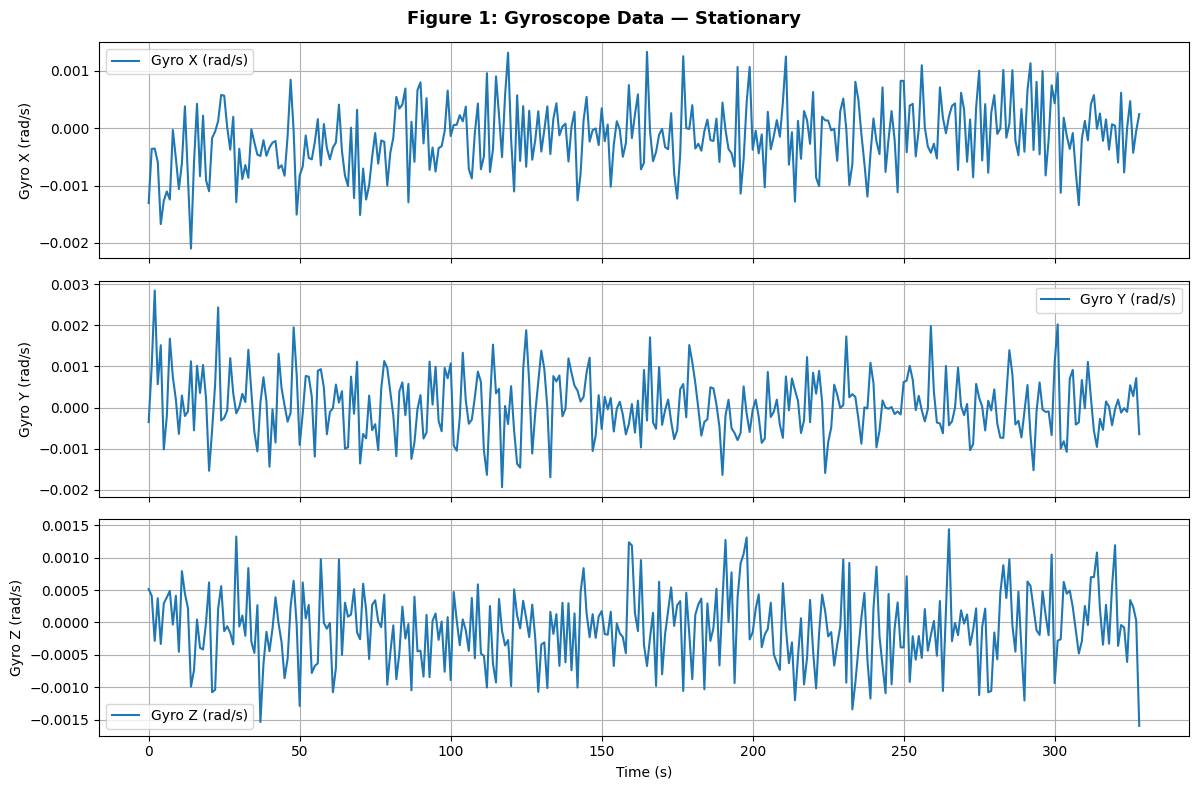

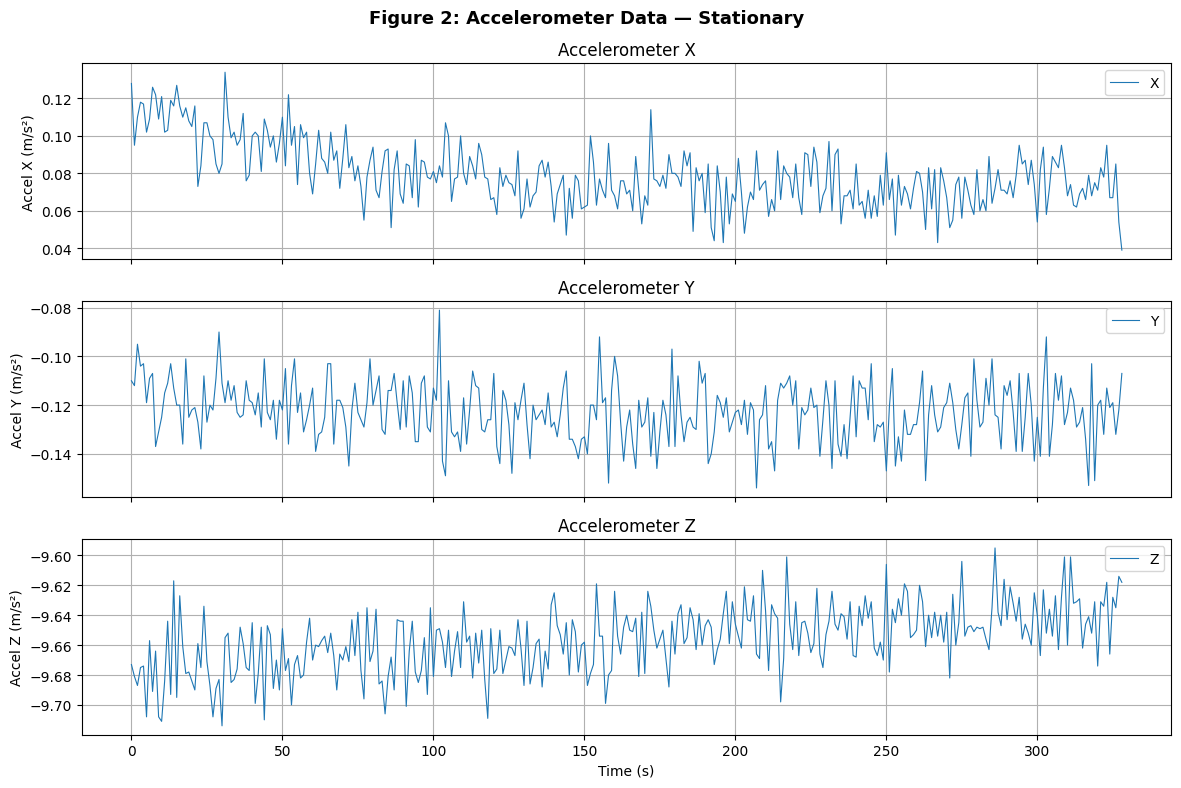

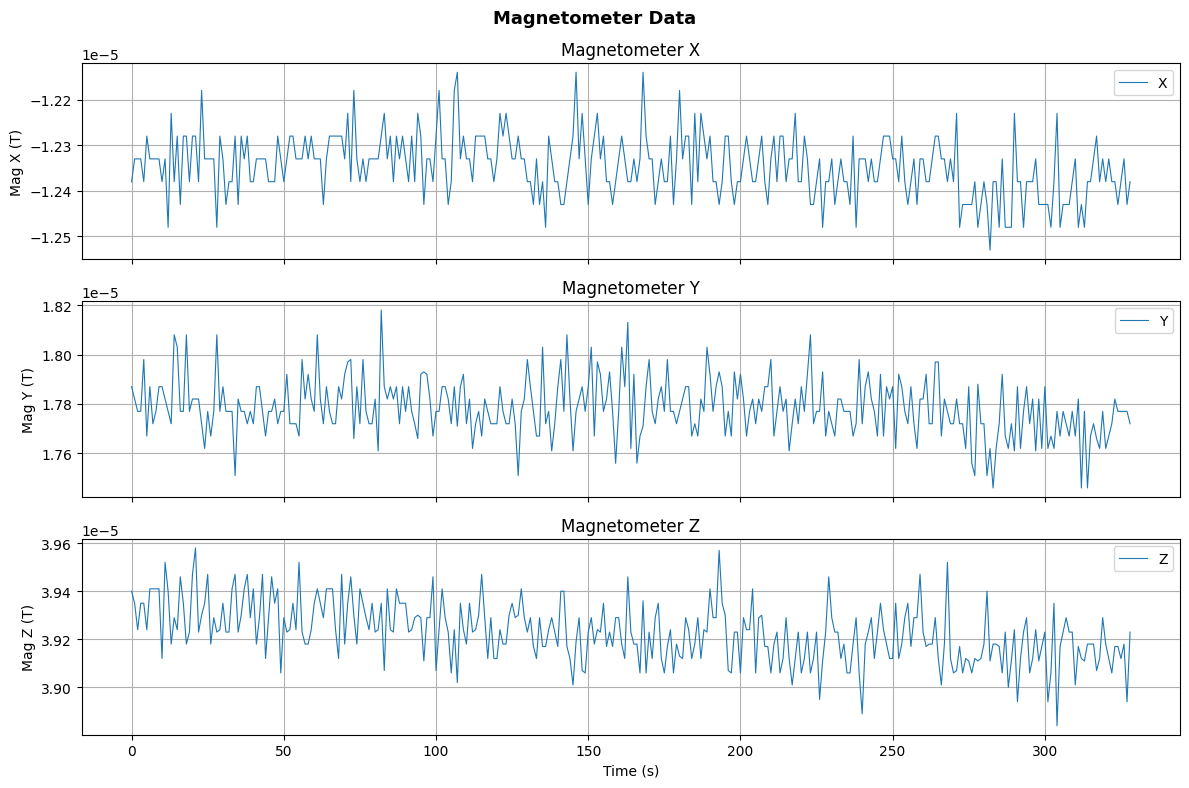

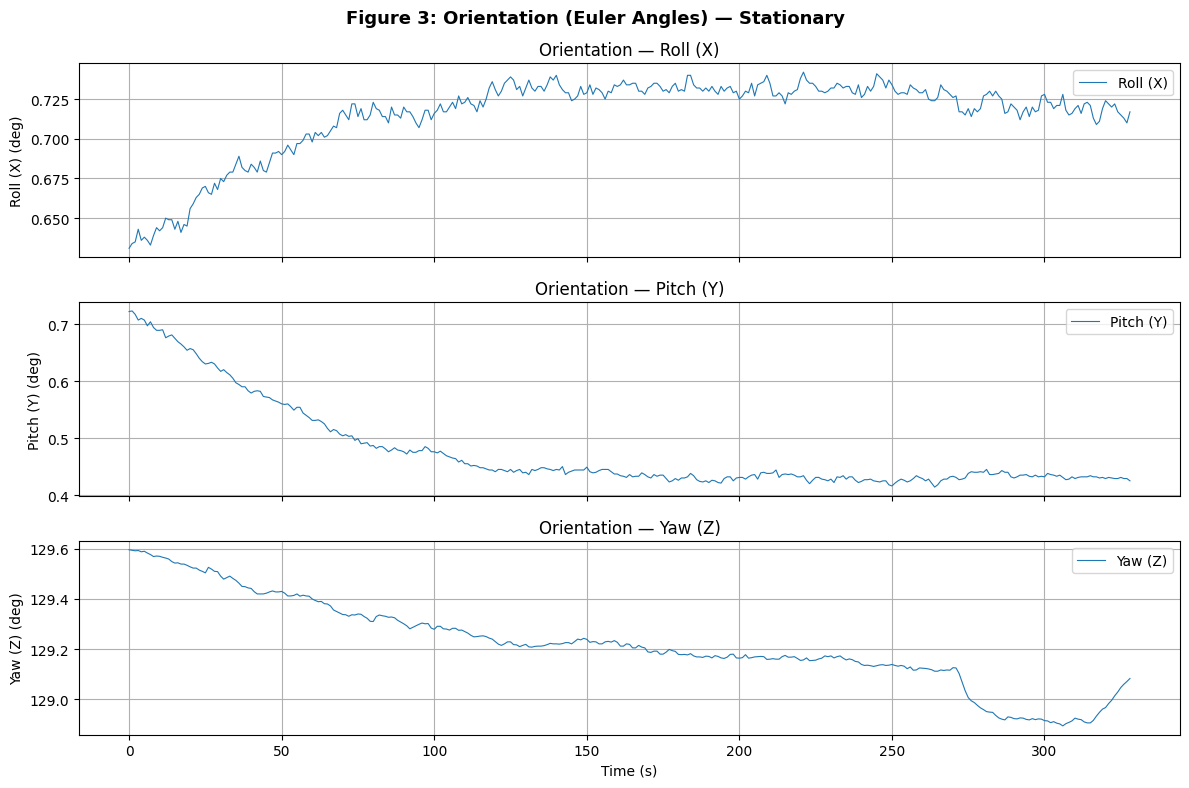

Axis           Mean (deg)   Median (deg)
----------------------------------------
Roll (X)           0.7151         0.7240
Pitch (Y)          0.4770         0.4400
Yaw (Z)          129.2206       129.2090


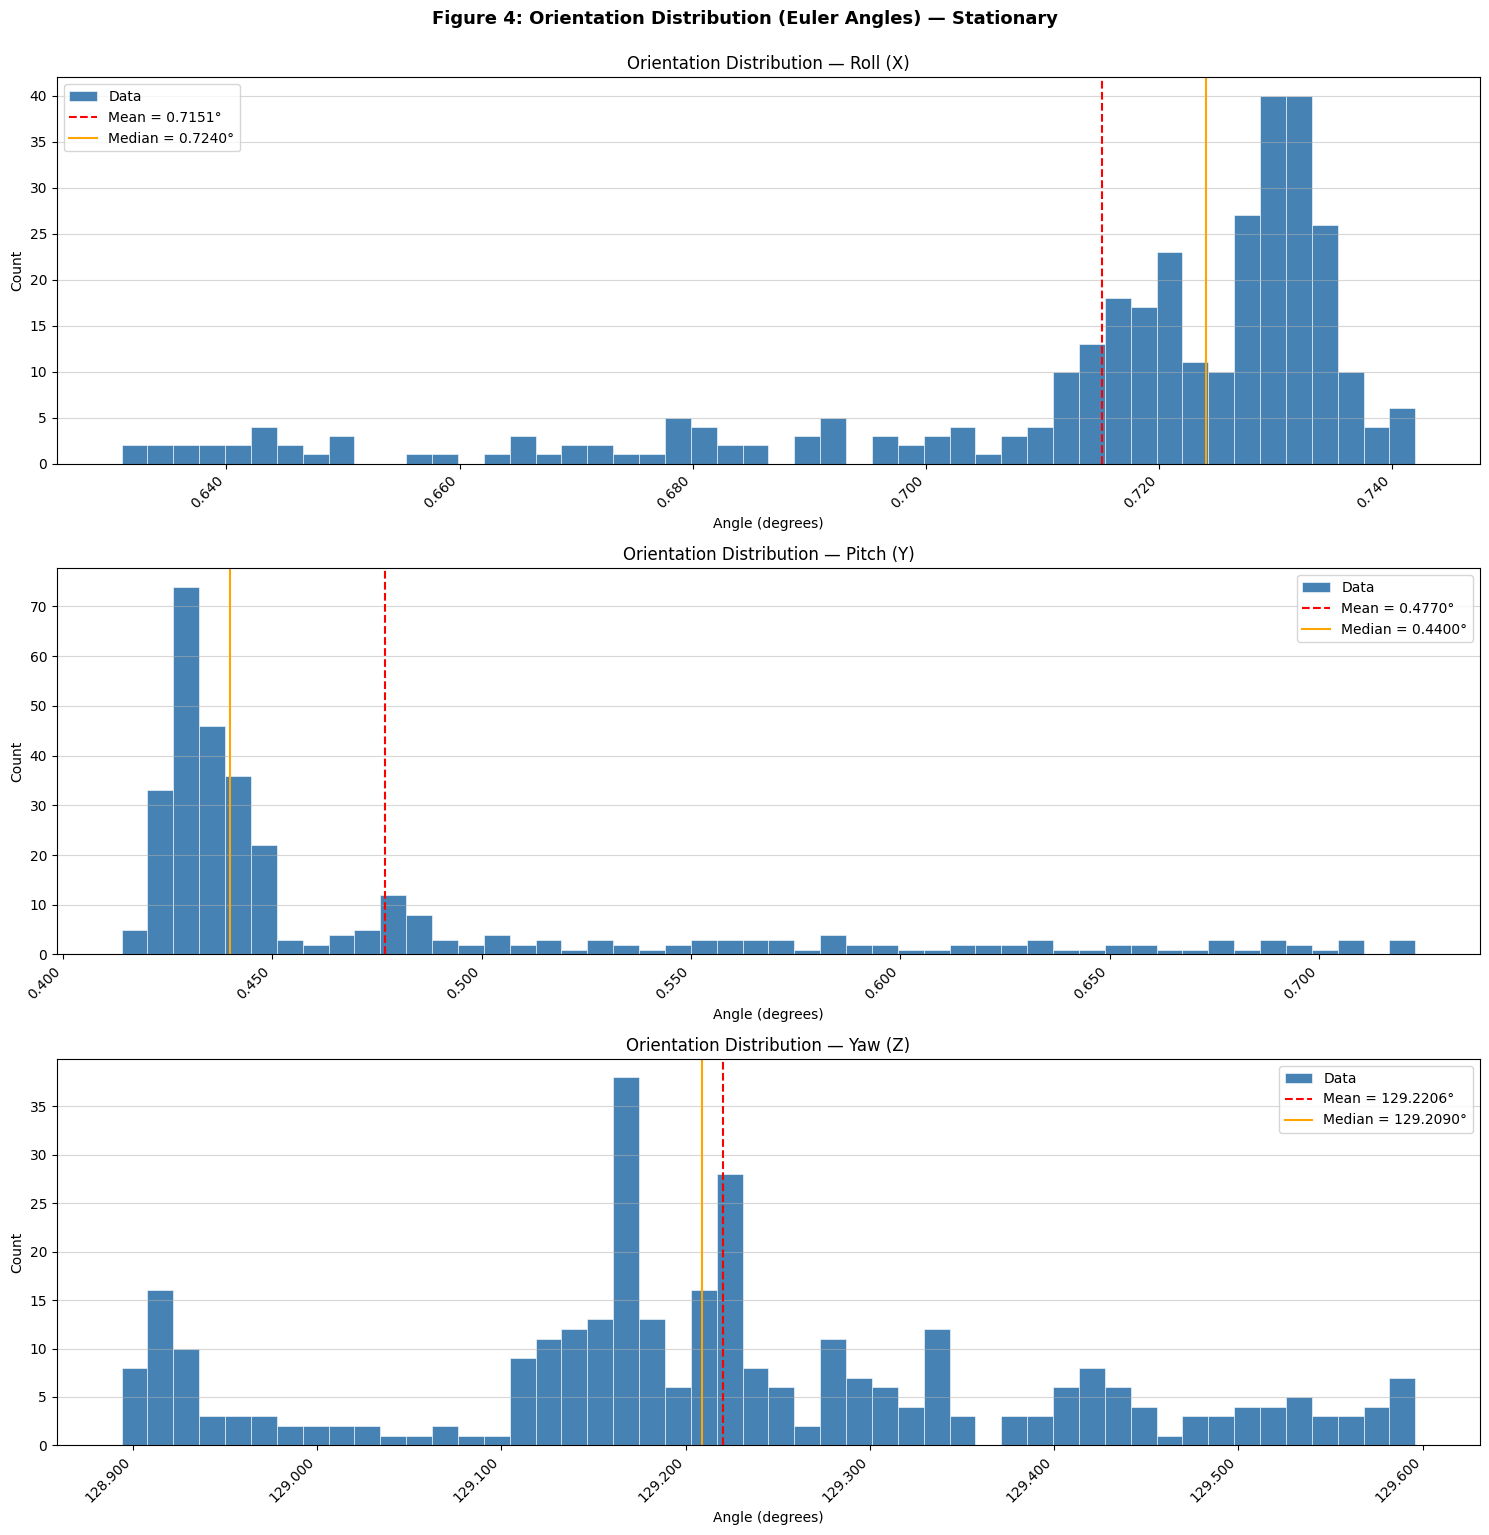

In [145]:
plot_gyro(df_stationary, title="Figure 1: Gyroscope Data — Stationary", save_fig=True)
plot_accel(df_stationary, title="Figure 2: Accelerometer Data — Stationary", save_fig=True)
plot_mag(df_stationary)
plot_orientation(df_stationary, title="Figure 3: Orientation (Euler Angles) — Stationary", save_fig=True)
print_orientation_stats(df_stationary)
plot_orientation_histograms(df_stationary, title="Figure 4: Orientation Distribution (Euler Angles) — Stationary", save_fig=True)

## Step 1: Find interesting motion windows
Run the full plots above, then note the `time_s` values where interesting motion happens.
Use `plot_clip` below to zoom in on any 5-second (or longer) window.

In [143]:
def plot_full_grouped(df, plots=("gyro", "accel", "orientation"), title="Full IMU Recording"):

    plot_config = {
        "gyro": {
            "columns": ["gyro_x", "gyro_y", "gyro_z"],
            "ylabel": "Angular Velocity\n(rad/s)",
        },
        "accel": {
            "columns": ["accel_x", "accel_y", "accel_z"],
            "ylabel": "Linear Acceleration\n(m/s²)\n(gravity removed)",
        },
        "orientation": {
            "columns": ["roll_deg", "pitch_deg", "yaw_deg"],
            "ylabel": "Orientation\n(deg)",
        },
    }

    # Filter to only valid, requested plots (preserving order)
    selected = [p for p in plots if p in plot_config]

    if not selected:
        raise ValueError(f"No valid plots selected. Choose from: {list(plot_config.keys())}")

    fig, axes = plt.subplots(len(selected), 1, figsize=(14, 4 * len(selected)), sharex=True)

    # Ensure axes is always iterable (edge case: only 1 subplot)
    if len(selected) == 1:
        axes = [axes]

    for ax, plot_name in zip(axes, selected):
        config = plot_config[plot_name]
        for col in config["columns"]:
            ax.plot(df["time_s"], df[col], linewidth=0.8, label=col)
        ax.set_ylabel(config["ylabel"])
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()                                                          


In [144]:
# define the time range for the clip (in seconds)
t1_start, t1_end = 24, 30  # find your timestamp
t2_start, t2_end = 119, 124  # find your timestamp

t1_df = df[(df["time_s"] >= t1_start) & (df["time_s"] <= t1_end)]
plot_accel(t1_df)
plot_orientation(t1_df)

NameError: name 'df' is not defined

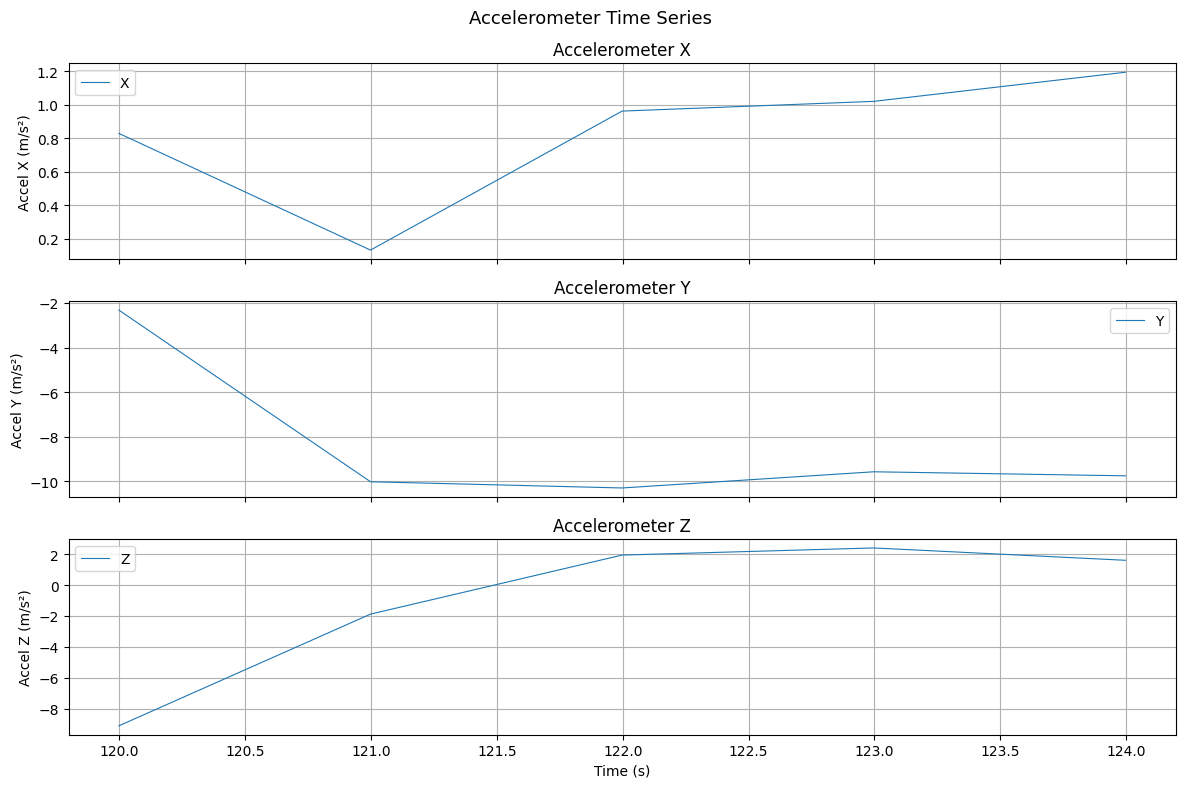

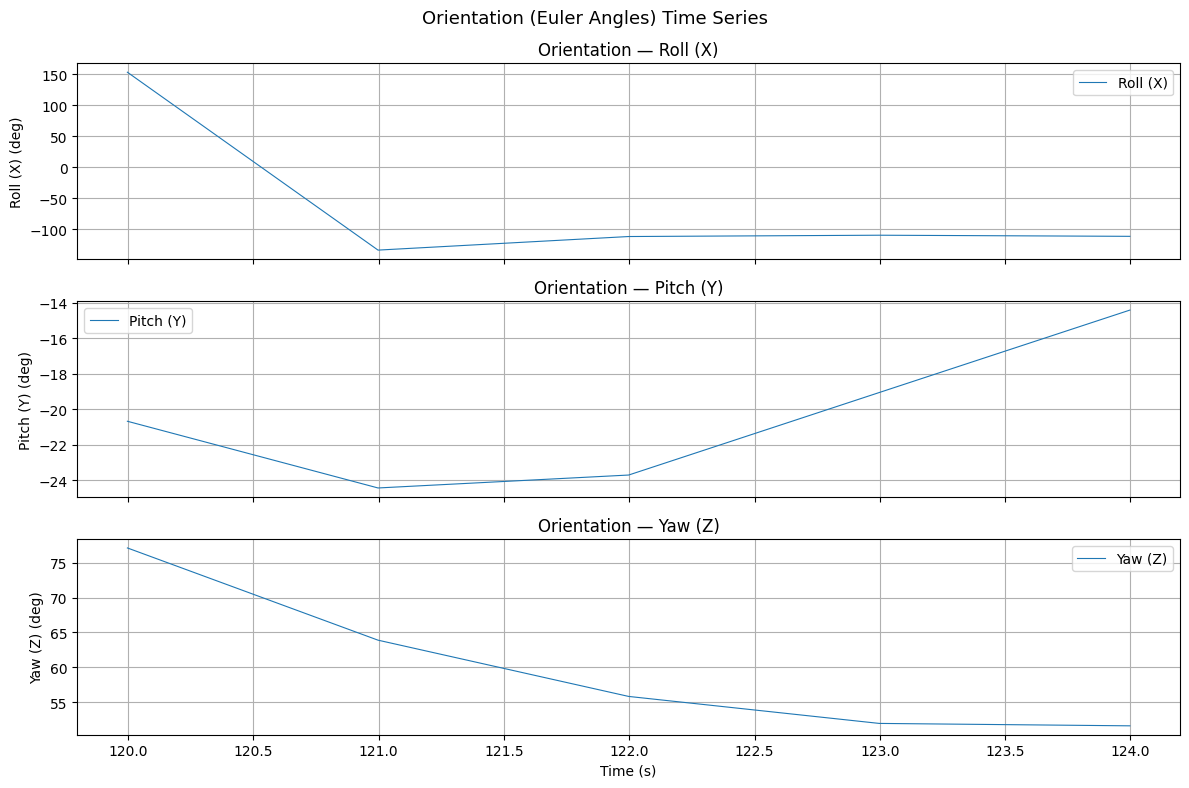

In [ ]:
t2_df = df[(df["time_s"] >= t2_start) & (df["time_s"] <= t2_end)]
plot_accel(t2_df)
plot_orientation(t2_df)

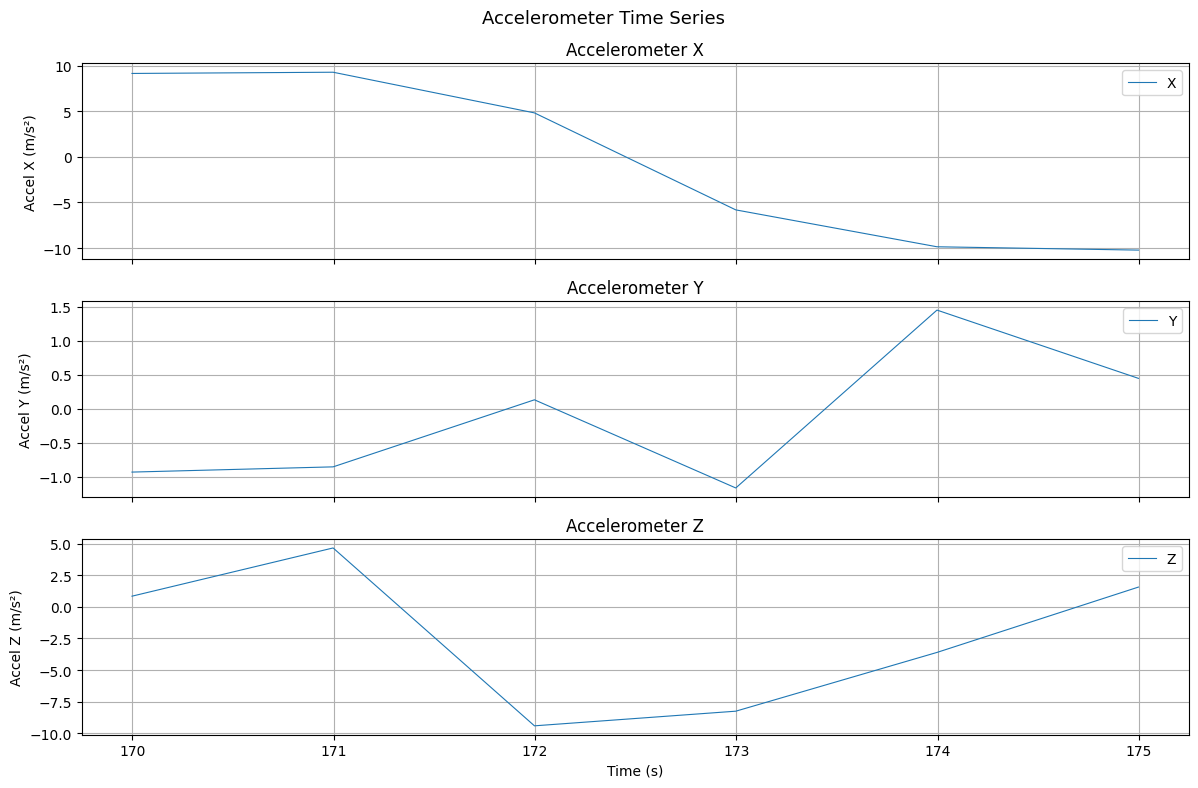

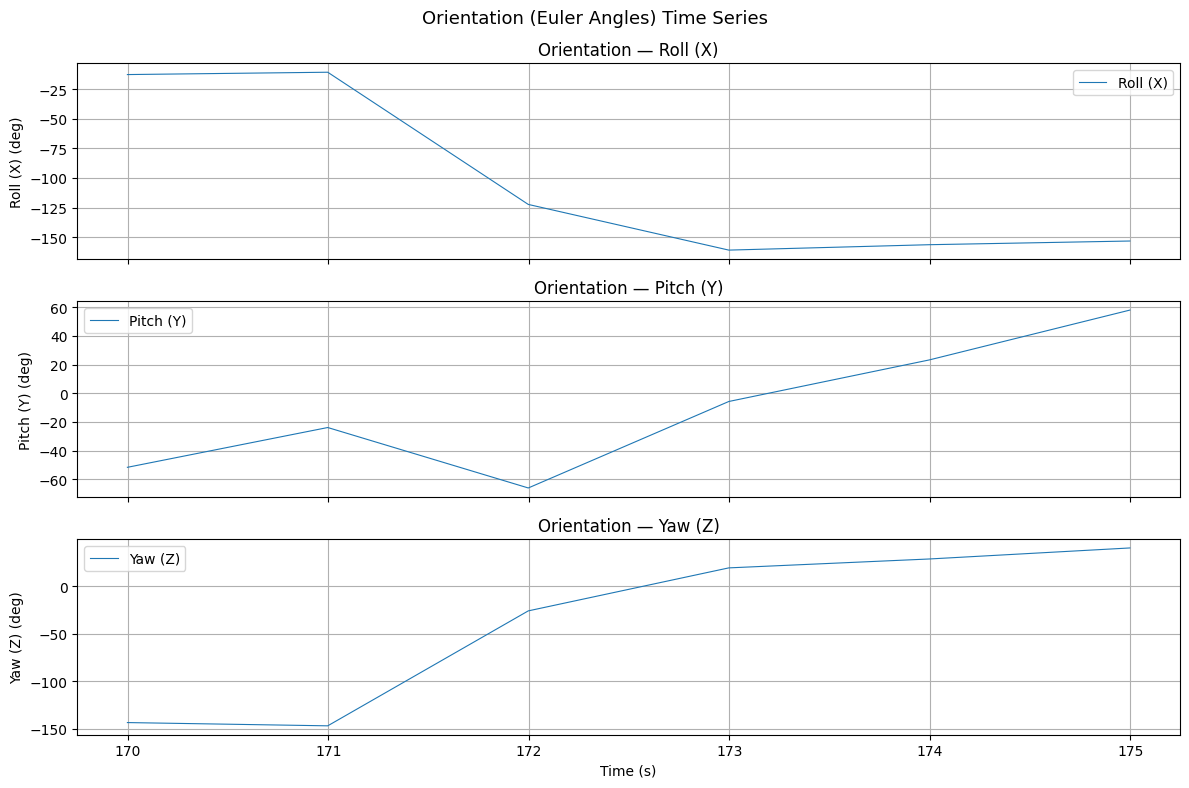

In [ ]:
t3_start, t3_end = 169, 175   
t3_df = df[(df["time_s"] >= t3_start) & (df["time_s"] <= t3_end)]
plot_accel(t3_df)
plot_orientation(t3_df)

# Allan Variance

In [ ]:
BAG_PATH = NOTEBOOK_DIR.parents[1] / "src/data/imu_bag_1"
# imu_bag_1 was recorded with type "custom_interfaces/msg/IMUmsg" — register under that name too
register_msg_file(typestore, MSG_PATH, "custom_interfaces/msg/IMUmsg")
df2 = bag_to_df_imu(BAG_PATH, typestore, topic=IMU_TOPIC)


gyro_x: N=0.0017, K=1.06e-06, B=1.19e-04
gyro_y: N=0.0001, K=6.00e-08, B=8.31e-06
gyro_z: N=0.0001, K=1.58e-07, B=3.75e-06


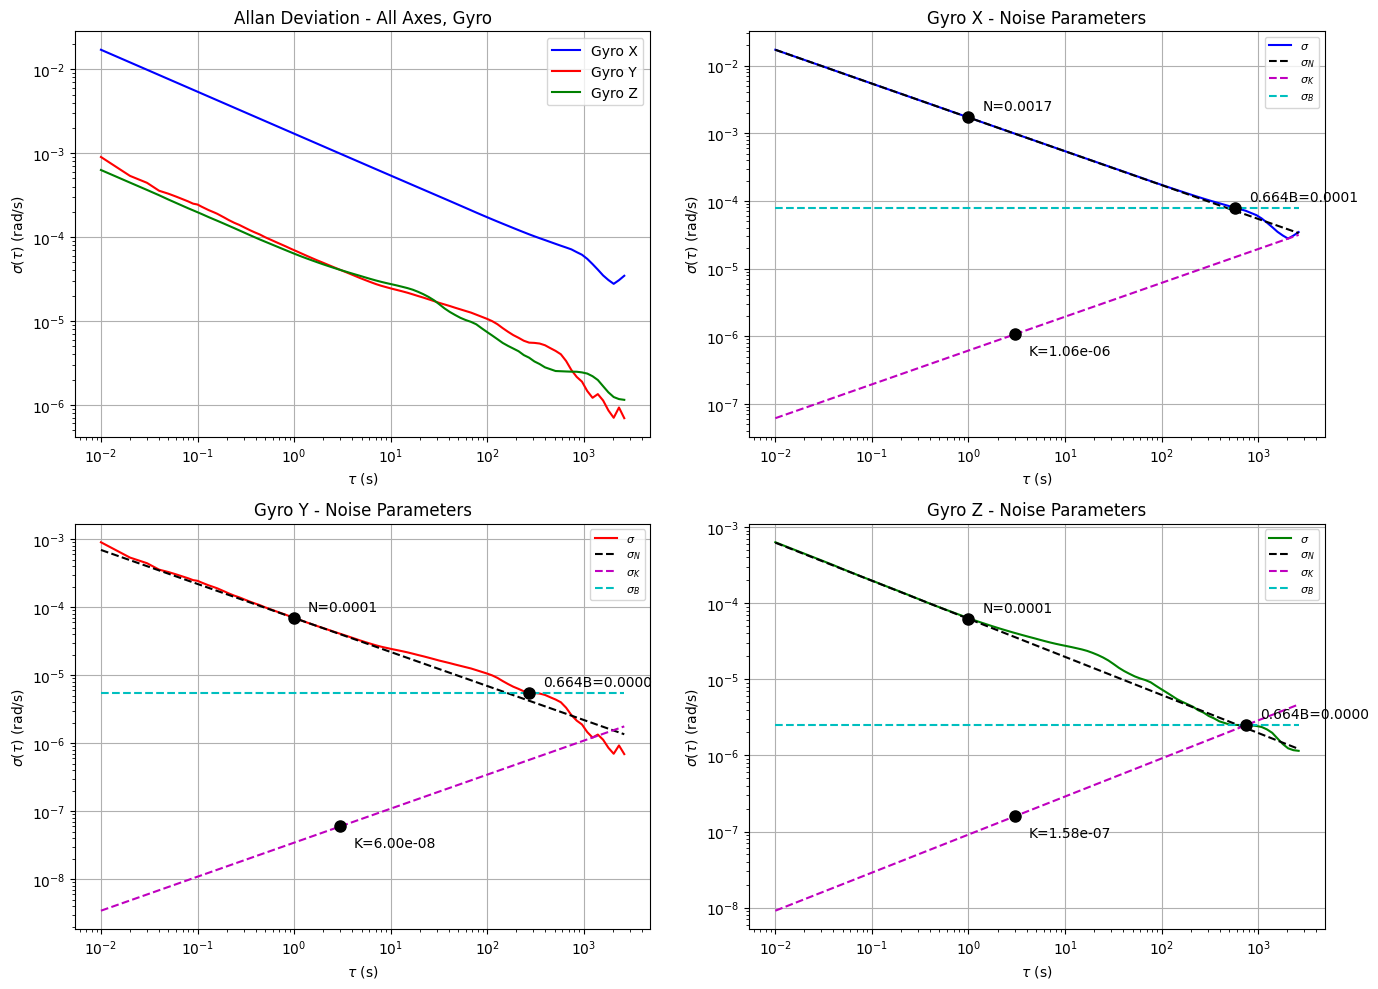

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 100
t0 = 1 / Fs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_all = axes[0, 0]  # top-left: all axes together
ax_per = [axes[0, 1], axes[1, 0], axes[1, 1]]  # one per axis

colors = ['blue', 'red', 'green']
labels = ['Gyro X', 'Gyro Y', 'Gyro Z']

for j, axis in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
    omega = df2[axis].values
    theta = np.cumsum(omega) * t0

    maxNumM = 100
    L = len(theta)
    maxM = 2 ** int(np.floor(np.log2(L / 2)))
    m = np.logspace(np.log10(1), np.log10(maxM), maxNumM)
    m = np.ceil(m).astype(int)
    m = np.unique(m)
    tau = m * t0

    avar = np.zeros(len(m))
    for i, mi in enumerate(m):
        avar[i] = np.sum(
            (theta[2*mi:L] - 2*theta[mi:L-mi] + theta[:L-2*mi]) ** 2
        )
    avar = avar / (2 * tau**2 * (L - 2*m))
    adev = np.sqrt(avar)

    N = angle_random_walk(tau, adev)
    K = rate_random_walk(tau, adev)
    B, scfB = bias_instability(tau, adev)

    print(f"{axis}: N={N:.4f}, K={K:.2e}, B={B:.2e}")

    lineN = N / np.sqrt(tau)
    lineK = K * np.sqrt(tau / 3)
    lineB = B * scfB * np.ones(len(tau))

    # Top-left: all axes overlaid
    ax_all.loglog(tau, adev, color=colors[j], label=labels[j])

    # Individual subplot
    ax = ax_per[j]
    ax.loglog(tau, adev, color=colors[j], label=r'$\sigma$')
    ax.loglog(tau, lineN, 'k--', label=r'$\sigma_N$')
    ax.loglog(tau, lineK, 'm--', label=r'$\sigma_K$')
    ax.loglog(tau, lineB, 'c--', label=r'$\sigma_B$')

    # Mark the key points
    ax.plot(1, N, 'ko', markersize=8)
    ax.annotate(f'N={N:.4f}', xy=(1, N), textcoords="offset points", xytext=(10, 5))

    ax.plot(3, K, 'ko', markersize=8)
    ax.annotate(f'K={K:.2e}', xy=(3, K), textcoords="offset points", xytext=(10, -15))

    tau_B = tau[np.argmin(np.abs(np.diff(np.log10(adev)) / np.diff(np.log10(tau))))]
    ax.plot(tau_B, B * scfB, 'ko', markersize=8)
    ax.annotate(f'0.664B={B*scfB:.4f}', xy=(tau_B, B*scfB), textcoords="offset points", xytext=(10, 5))

    ax.set_title(f'{labels[j]} - Noise Parameters')
    ax.set_xlabel(r'$\tau$ (s)')
    ax.set_ylabel(r'$\sigma(\tau)$ (rad/s)')
    ax.legend(fontsize=8)
    ax.grid(True)

ax_all.set_title('Allan Deviation - All Axes, Gyro')
ax_all.set_xlabel(r'$\tau$ (s)')
ax_all.set_ylabel(r'$\sigma(\tau)$ (rad/s)')
ax_all.legend()
ax_all.grid(True)

plt.tight_layout()
plt.show()

gyro_x: N=0.0017, K=1.06e-06, B=1.19e-04
gyro_y: N=0.0001, K=6.00e-08, B=8.31e-06
gyro_z: N=0.0001, K=1.58e-07, B=3.75e-06


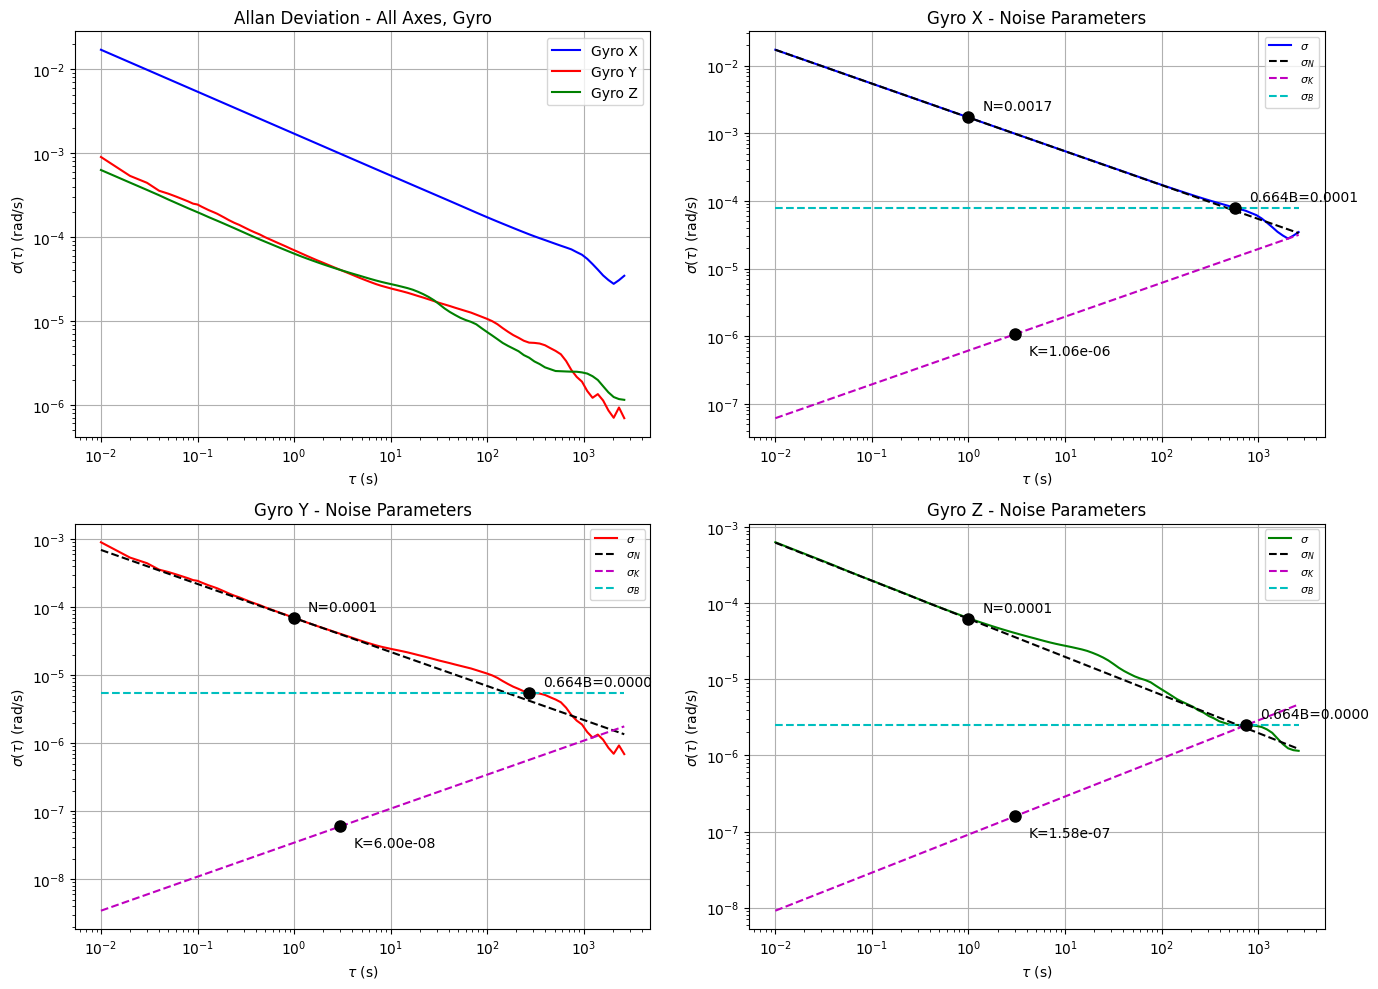